<a href="https://colab.research.google.com/github/Sawa-Ishikawa38/diabetes-analysis-bmi-waist-hba1c/blob/main/metabolic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Introduction

## Clinical question
##Which is more strongly associated with poor glycaemic control of type 2 diabetes, BMI or waist circumfence?

## Background
It is widely known that type2 diabetes is primarily caused by increased insulin resitance, which is mainly attributed to excess body fat, particularly when it is stored as visceral fat, while other factors such as genetics, ages, diets and muscle volume, may play roles.


From my early clinical experience, I have seen a lot of cases of type 2 diabetes where the focus of treatment goal aside from controling HbA1c is reducing patients' weights,  rather than waist circumfences, aiming for a normal BMI.


Moreover, there has been a both clinically and epidemiologically controversial assumption that BMI is a quick marker for general metabolic signals.

As waist circumfence tend to reflect visceral more directly than BMI, which is a reflection of overall body mass, I tried to examine a hypothesis through this analysis, that waist circumference could be associated more strongly than BMI with increased insulin resistance, resulting in poor glycaemic control in type 2 diabetes.






# 1. Data selection

## 1-1. diabetes type (type1 vs type2)
I excluded patients data with type1 diabetes, as the clinical question mentioned above is purely about the relationships between common obesity indexes and insulin resistance, while type1 diabetes also involves other mechanism than insulin resistance, which is autoimmune condition.

## 1-2. index for glycaemic control (HbA1c vs 'glucose')

### HbA1c was used as the primary marker of long-term glycaemic control in this analysis for the following reasons;

* In general, HbA1c reflects long-term blood glucose level, less affected by day-to-day variation, and therefore used clinically for long-term diabetes control. While it can be affected by other factors such as red blood cell lifespan or renal disease, it is still reliable on population-level.

* In general, blood glucose is prone to high variability, strongly affected by fasting or non-fasting
* In this database, the 'glucose' variable is the only marker of glycaemic status available; however, the timing and type of measurement (fasting, random, post-prandial, or even a simulated mixture of all) is not specified, while each of them could have a clinically different meaning for 'glycaemic control'.





# 2. Import data / Check data structure





In [2]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/hdg204/DoctorsAsDataScientists/main/metabolic_data.csv')
df.head()

,id,yob,sex,age,centre,ethnicity,packyears,smoking_status,age_diabetes,diabetes,...,height,hip_circ,waist_circ,bmi,t2d_grs,t1d_date,t2d_date,hypertension_date,mi_date,tdi
0,1,1953,Male,55.516195,Centre1,White,20.973638,Current,NaN,0,...,175.642362,96.896600,92.222113,25.061071,-0.966474,NaN,NaN,NaN,NaN,5.098209
1,2,1951,Female,58.158580,Centre2,White,15.024332,Former,NaN,0,...,164.393074,96.098721,80.487276,27.127083,-0.115997,NaN,NaN,1992-05-01,NaN,-0.592757
2,3,1937,Male,72.469667,Centre1,White,18.168200,Current,NaN,0,...,182.108980,106.197760,105.468038,33.868504,0.862375,NaN,NaN,NaN,NaN,-1.744062
3,4,1951,Female,60.564067,Centre2,Black,0.000000,Never,NaN,0,...,169.807407,101.655709,85.201025,25.787610,-0.784950,NaN,NaN,2003-05-01,NaN,-0.356159
4,5,1950,Female,61.034302,Centre1,White,31.930285,Former,NaN,0,...,162.172179,101.181175,87.247610,30.386791,-0.379706,NaN,NaN,NaN,NaN,-1.124817


In [4]:
df['ethnicity'].unique()

array(['White', 'Black', 'Other', 'SouthAsian', 'EastAsian'], dtype=object)

In [ ]:
df['smoking_status'].unique()

array(['Current', 'Former', 'Never'], dtype=object)

In [ ]:
df.shape

(50000, 27)

In [ ]:
df.columns

Index(['id', 'yob', 'sex', 'age', 'centre', 'ethnicity', 'packyears',
       'smoking_status', 'age_diabetes', 'diabetes', 'dbp', 'sbp', 'hdl',
       'ldl', 'glucose', 'hba1c', 'weight', 'height', 'hip_circ', 'waist_circ',
       'bmi', 't2d_grs', 't1d_date', 't2d_date', 'hypertension_date',
       'mi_date', 'tdi'],
      dtype='object')

## note: what each column refers to
t2d_grs: a genetic risk score for type 2 diabetes. mi_date:myocardial infarction date. Tdi:Townsend deprivation inde
packyears: the amount of cigarette per week, multiplied by years of smoking  

# 3. Data cleaning

## Data selection1

In [5]:
# extract patients with diabetes
dm = df[df['diabetes'] == 1]
print(dm)

          id   yob     sex        age   centre ethnicity  packyears  \
6          7  1944  Female  63.687330  Centre2     White  20.872706   
25        26  1963    Male  46.506454  Centre4     Black   0.000000   
38        39  1955  Female  57.552299  Centre2     White  32.470908   
43        44  1932    Male  77.351648  Centre4     White   0.000000   
44        45  1940    Male  69.663696  Centre4     White   0.000000   
...      ...   ...     ...        ...      ...       ...        ...   
49982  49983  1948    Male  60.002776  Centre4     Other   0.000000   
49983  49984  1948    Male  62.475564  Centre2     White  40.428767   
49985  49986  1946    Male  62.849527  Centre2     White  22.959200   
49994  49995  1949  Female  60.426649  Centre3     White  25.731773   
49998  49999  1952  Female  59.753647  Centre4     Black  29.232355   

      smoking_status  age_diabetes  diabetes  ...      height    hip_circ  \
6             Former     43.091283         1  ...  162.432777   91.744

In [11]:
# check data in dm
first = dm.loc[6]
print(first)

id                            7
yob                        1944
sex                      Female
age                    63.68733
centre                  Centre2
ethnicity                 White
packyears             20.872706
smoking_status           Former
age_diabetes          43.091283
diabetes                      1
dbp                   82.614969
sbp                  141.195224
hdl                    1.289939
ldl                    3.239685
glucose                6.996579
hba1c                 51.502871
weight                73.183324
height               162.432777
hip_circ              91.744858
waist_circ            83.385124
bmi                   27.555382
t2d_grs               -0.316574
t1d_date                    NaN
t2d_date             1987-07-01
hypertension_date           NaN
mi_date                     NaN
tdi                    4.387615
Name: 6, dtype: object


## Check missing data

In [16]:
# check missing data in dm
dm.isna().sum()

,0
id,0
yob,0
sex,0
age,0
centre,0
ethnicity,0
packyears,0
smoking_status,0
age_diabetes,0
diabetes,0


* 3/8120 patients don't have NaN in 't1d_date'

In [17]:
# check the 3 data with no missing in 't1d_date'
dm_t1 = dm[dm['t1d_date'].notna()]
print(dm_t1)

          id   yob     sex        age   centre ethnicity  packyears  \
16803  16804  1939    Male  66.704227  Centre2     White   0.000000   
25873  25874  1956  Female  57.578125  Centre4     White  10.489689   
36476  36477  1955    Male  57.382386  Centre4     White   0.000000   

      smoking_status  age_diabetes  diabetes  ...      height    hip_circ  \
16803          Never     66.555007         1  ...  169.821275   95.193808   
25873         Former     54.193004         1  ...  166.220433  100.420519   
36476          Never     55.336476         1  ...  173.121332  100.430709   

       waist_circ        bmi   t2d_grs    t1d_date    t2d_date  \
16803   93.871473  27.282514  0.286257  1948-03-01  2006-07-01   
25873   92.992944  30.908688  1.941519  1967-03-01  2010-07-01   
36476   87.078840  25.606741 -1.642958  1966-03-01  2010-07-01   

       hypertension_date  mi_date       tdi  
16803         2005-05-01      NaN -1.713921  
25873                NaN      NaN -0.134765  
364



*  the 3 patients seem to have both type1&type2 diabetes


* let's remove them and extract patients with only type2 diabetes





## Data selection2

In [6]:
# extract patients only with type2 diabetes
t2 = dm[dm['t1d_date'].isna()].copy()
# make a new column of mean blood pressure
t2['bp'] = t2['dbp'] + (t2['sbp'] - t2['dbp'])/3
print(t2)

          id   yob     sex        age   centre ethnicity  packyears  \
6          7  1944  Female  63.687330  Centre2     White  20.872706   
25        26  1963    Male  46.506454  Centre4     Black   0.000000   
38        39  1955  Female  57.552299  Centre2     White  32.470908   
43        44  1932    Male  77.351648  Centre4     White   0.000000   
44        45  1940    Male  69.663696  Centre4     White   0.000000   
...      ...   ...     ...        ...      ...       ...        ...   
49982  49983  1948    Male  60.002776  Centre4     Other   0.000000   
49983  49984  1948    Male  62.475564  Centre2     White  40.428767   
49985  49986  1946    Male  62.849527  Centre2     White  22.959200   
49994  49995  1949  Female  60.426649  Centre3     White  25.731773   
49998  49999  1952  Female  59.753647  Centre4     Black  29.232355   

      smoking_status  age_diabetes  diabetes  ...    hip_circ  waist_circ  \
6             Former     43.091283         1  ...   91.744858   83.385

In [15]:
print(t2.dtypes)

id                     int64
yob                    int64
sex                   object
age                  float64
centre                object
ethnicity             object
packyears            float64
smoking_status        object
age_diabetes         float64
diabetes               int64
dbp                  float64
sbp                  float64
hdl                  float64
ldl                  float64
glucose              float64
hba1c                float64
weight               float64
height               float64
hip_circ             float64
waist_circ           float64
bmi                  float64
t2d_grs              float64
t1d_date              object
t2d_date              object
hypertension_date     object
mi_date               object
tdi                  float64
bp                   float64
dtype: object


## Convert categorical variables

In [7]:
# one-hot coding with 'ethnicity' and 'smoking_status' columns
T2 = pd.get_dummies(t2, columns=['ethnicity','smoking_status'], drop_first=True)
# binary mapping with 'sex' columns
T2['sex_binary'] = T2['sex'].map({'Female':0, 'Male':1})
print(T2)

          id   yob     sex        age   centre  packyears  age_diabetes  \
6          7  1944  Female  63.687330  Centre2  20.872706     43.091283   
25        26  1963    Male  46.506454  Centre4   0.000000     43.920149   
38        39  1955  Female  57.552299  Centre2  32.470908     50.778852   
43        44  1932    Male  77.351648  Centre4   0.000000     43.066904   
44        45  1940    Male  69.663696  Centre4   0.000000     65.661294   
...      ...   ...     ...        ...      ...        ...           ...   
49982  49983  1948    Male  60.002776  Centre4   0.000000     51.550242   
49983  49984  1948    Male  62.475564  Centre2  40.428767     56.540734   
49985  49986  1946    Male  62.849527  Centre2  22.959200     55.120157   
49994  49995  1949  Female  60.426649  Centre3  25.731773     55.424056   
49998  49999  1952  Female  59.753647  Centre4  29.232355     50.705643   

       diabetes        dbp         sbp  ...  mi_date       tdi          bp  \
6             1  82.6

# 4. Check Correlation

In [ ]:
#check correlation between each variable
T2[['age', 'sex_binary','bp', 'packyears', 'ethnicity_EastAsian', 'ethnicity_Other', 'ethnicity_SouthAsian', 'ethnicity_White', 'smoking_status_Former', 'smoking_status_Never', 'ldl', 'bmi','waist_circ','hba1c']].corr()

,age,sex_binary,bp,packyears,ethnicity_EastAsian,ethnicity_Other,ethnicity_SouthAsian,ethnicity_White,smoking_status_Former,smoking_status_Never,ldl,bmi,waist_circ,hba1c
age,1.000000,-0.011752,0.460661,0.251610,-0.014642,0.000880,-0.001046,-0.006405,0.011205,-0.116558,0.397059,0.259798,0.127773,0.062029
sex_binary,-0.011752,1.000000,-0.011473,0.002291,0.010568,-0.007090,-0.018826,0.011566,0.012730,-0.008014,-0.029073,-0.064799,0.607698,-0.029997
bp,0.460661,-0.011473,1.000000,0.210146,-0.016897,-0.002398,0.044559,-0.034253,-0.011966,-0.155243,0.216069,0.293563,0.166249,0.095501
packyears,0.251610,0.002291,0.210146,1.000000,-0.031973,-0.004367,0.017823,-0.017244,0.510726,-0.868557,0.104441,0.139864,0.079877,0.040884
ethnicity_EastAsian,-0.014642,0.010568,-0.016897,-0.031973,1.000000,-0.044798,-0.068042,-0.332247,-0.014161,0.034819,-0.014413,-0.024977,-0.046195,-0.006737
ethnicity_Other,0.000880,-0.007090,-0.002398,-0.004367,-0.044798,1.000000,-0.073885,-0.360778,-0.009534,-0.000453,-0.006550,-0.002386,-0.007332,0.000082
ethnicity_SouthAsian,-0.001046,-0.018826,0.044559,0.017823,-0.068042,-0.073885,1.000000,-0.547970,0.010869,-0.027580,0.025469,0.115845,-0.016055,0.017547
ethnicity_White,-0.006405,0.011566,-0.034253,-0.017244,-0.332247,-0.360778,-0.547970,1.000000,-0.008124,0.024591,-0.018211,-0.110389,-0.014448,-0.009832
smoking_status_Former,0.011205,0.012730,-0.011966,0.510726,-0.014161,-0.009534,0.010869,-0.008124,1.000000,-0.611246,0.001803,0.020487,0.021342,0.001795
smoking_status_Never,-0.116558,-0.008014,-0.155243,-0.868557,0.034819,-0.000453,-0.027580,0.024591,-0.611246,1.000000,-0.046844,-0.116751,-0.072628,-0.032462




*   'waist_circ' and 'bmi' are moderately correlated(0.586)
*   'waist_circ' and 'sex_binary' are moderately correlated (0.608)



# 5. Multiple Linear Regression



## 5-1. Without Standardization (raw coefficients)

In [10]:
# convert boolean(T/F) in dummy columns to numbers(integers)
dummy_cols = ['ethnicity_EastAsian', 'ethnicity_Other', 'ethnicity_SouthAsian', 'ethnicity_White', 'smoking_status_Former', 'smoking_status_Never']
T2[dummy_cols] = T2[dummy_cols].astype(int)

# import statsmodel
import statsmodels.api as sm
x = T2[['age', 'sex_binary', 'ldl', 'bmi','bp','packyears','waist_circ', 'ethnicity_EastAsian', 'ethnicity_Other', 'ethnicity_SouthAsian', 'ethnicity_White', 'smoking_status_Former', 'smoking_status_Never']]
y = t2['hba1c']
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  hba1c   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     63.12
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          9.19e-159
Time:                        09:53:09   Log-Likelihood:                -22853.
No. Observations:                8127   AIC:                         4.573e+04
Df Residuals:                    8113   BIC:                         4.583e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    35.08



* 'bmi' looks most associated with outcome

*  The condition number is large probably because there are some multicollinearity (such as 'bmi'&'waist_circ') and/or scaling gap between variables.


## 5-2. With Standardization (comparable coefficients)

In [23]:
# convert boolean(T/F) in dummy columns to numbers(integers)
dummy_cols = ['ethnicity_EastAsian', 'ethnicity_Other', 'ethnicity_SouthAsian', 'ethnicity_White', 'smoking_status_Former', 'smoking_status_Never']
T2[dummy_cols] = T2[dummy_cols].astype(int)

# import statsmodel
import statsmodels.api as sm

# scaling: standardization of different units
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(T2[['age', 'sex_binary', 'ldl', 'bmi','bp','packyears','waist_circ', 'ethnicity_EastAsian', 'ethnicity_Other', 'ethnicity_SouthAsian', 'ethnicity_White', 'smoking_status_Former', 'smoking_status_Never']])
x_scaled = sm.add_constant(x_scaled)
y = T2['hba1c']
model = sm.OLS(y, x_scaled).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  hba1c   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     63.12
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          9.19e-159
Time:                        16:53:25   Log-Likelihood:                -22853.
No. Observations:                8127   AIC:                         4.573e+04
Df Residuals:                    8113   BIC:                         4.583e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.6729      0.045   1043.946      0.0

*note: interpretation of one hot encoding
 :

   ethnicity coefficients → compared to Black
   smoking coefficients → compared to Current



#6. Visualisation of raw data

## Scatter plot (BMI/HbA1c & Waist/HbA1c)

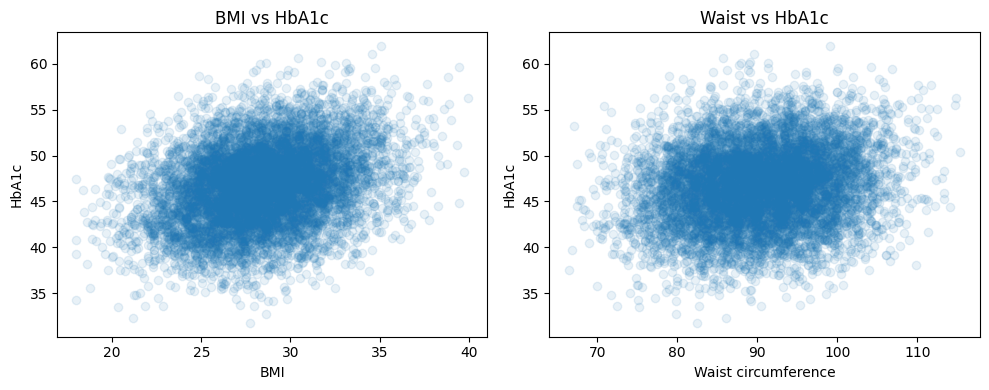

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

# BMI vs HbA1c
plt.subplot(1,2,1)
plt.scatter(T2['bmi'], T2['hba1c'], alpha=0.1)
plt.xlabel('BMI')
plt.ylabel('HbA1c')
plt.title('BMI vs HbA1c')

# Waist vs HbA1c
plt.subplot(1,2,2)
plt.scatter(T2['waist_circ'], T2['hba1c'], alpha = 0.1)
plt.xlabel('Waist circumference')
plt.ylabel('HbA1c')
plt.title('Waist vs HbA1c')

plt.tight_layout()
plt.show()

## Scatter plot with trend line

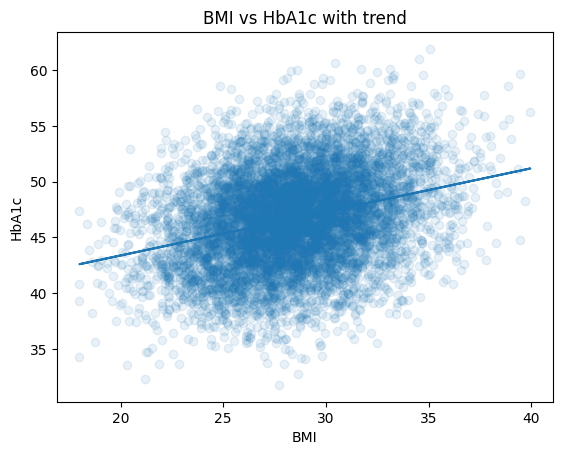

In [14]:
import numpy as np

# BMI plot
plt.scatter(T2['bmi'], T2['hba1c'], alpha = 0.1)

z = np.polyfit(T2['bmi'], T2['hba1c'], 1)
p = np.poly1d(z)

plt.plot(T2['bmi'], p(T2['bmi']))
plt.xlabel('BMI')
plt.ylabel('HbA1c')
plt.title('BMI vs HbA1c with trend')
plt.show()

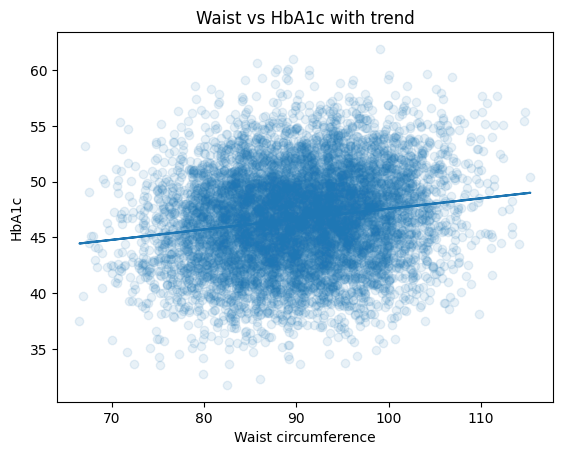

In [15]:
# Waist plot
plt.scatter(T2['waist_circ'], T2['hba1c'], alpha = 0.1)

z = np.polyfit(T2['waist_circ'], T2['hba1c'], 1)
p = np.poly1d(z)

plt.plot(T2['waist_circ'], p(T2['waist_circ']))
plt.xlabel('Waist circumference')
plt.ylabel('HbA1c')
plt.title('Waist vs HbA1c with trend')
plt.show()

#7. Result

## The coefficient of the independent variable 'bmi' on the dependent variable 'hba1c' is by far the largest among other variables, including 'waist_circ'

##

#8. Discussion

The result gained from this analysis contradicts the shifting clinical consensus that waist circumference is much more essential predictor of increased insulin resistance over BMI.

Here are the main three possible limitations behind this result that are unique to this particular analysis;


1. Given that the dataset is simulated, relationships are artificially generated, or variable dependencies may be just arbitrary. For example, an intentional data generation such as assigning stronger metabolic signals (including HbA1c and LDL)to BMI rather than waist circumfence, or, constructing HbA1c directly based on BMI, is possible, making BMI look more associated with HbA1c in disguise over waist circumference.

2. 'bmi' and 'waist_circ' variables have a moderate correlation in this model(corr = 0.6), which makes each coefficient unstable.

3. While 'waist_circ' also has a moderate correlation with 'sex_binary' (corr=0.61) in this dataset, 'bmi' is less overlapped with other variables, leaving more unique signal(coefficient) in this model,especially if BMI is strongly embedded in HbA1c data generation as mentioned above.






#9. Conclusion


## In this particular dataset and model, BMI appears to have stronger statistical association with poor glycaemic control of type2 diabetes over waist circumference, which contradicts the shifting clinical consensus.

## However, the nature of simulated dataset does not guarantee biological realism.

## Therefore, the hypothesis of waist circmference as a sharper indicator of increased insulin resistance cannot be verified from the given dataset.